# ANOVA
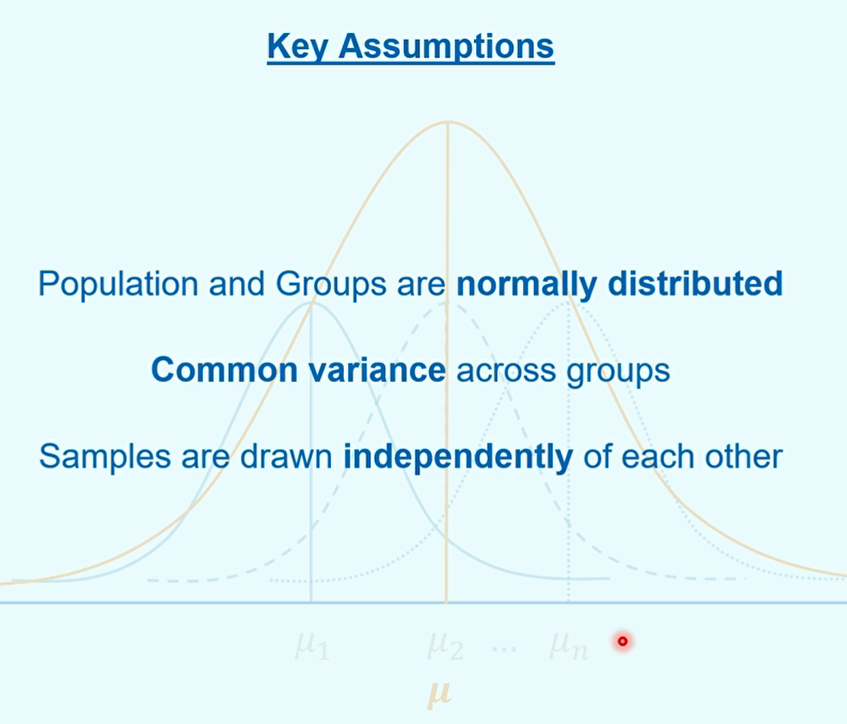
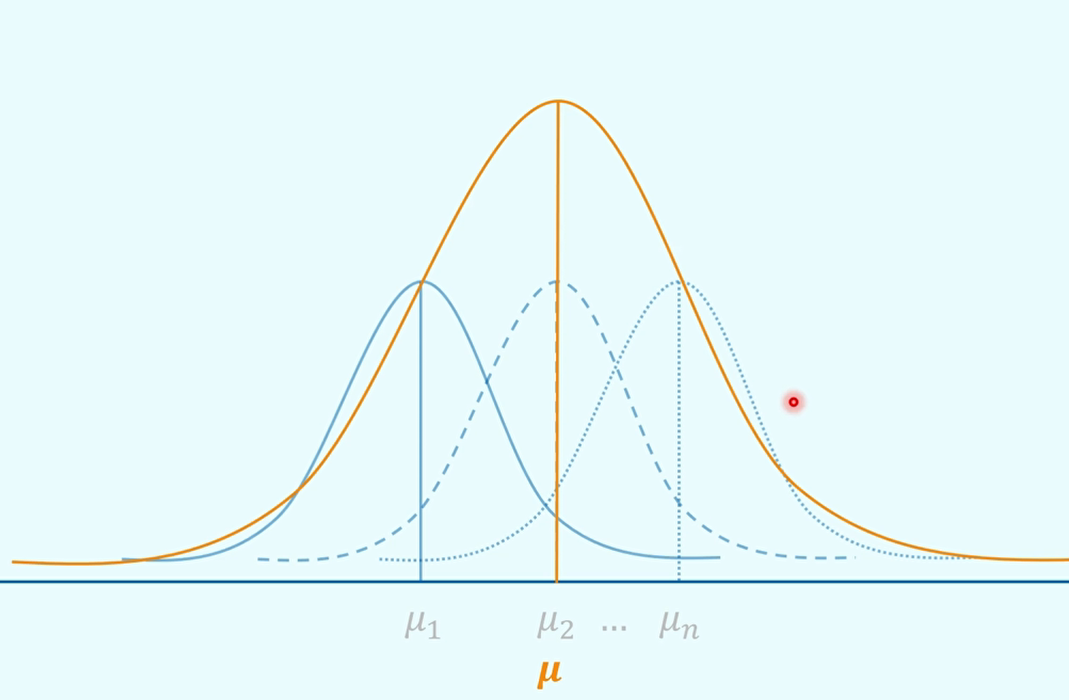
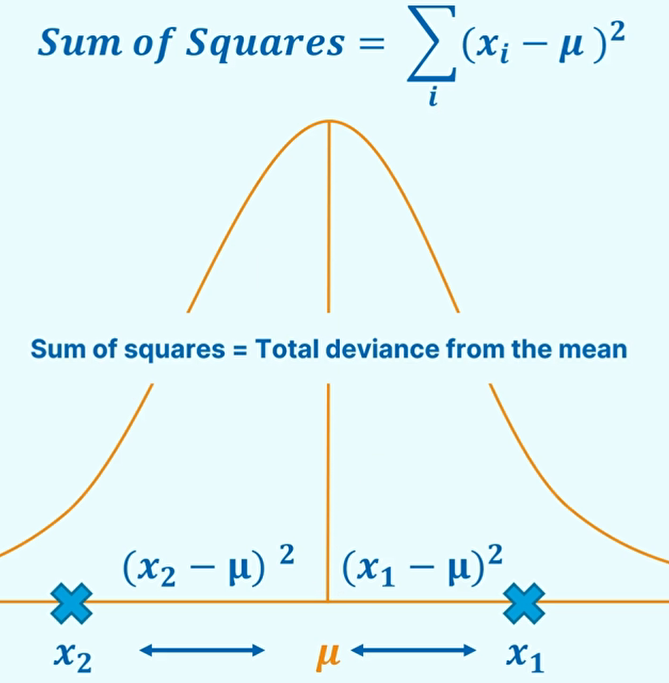
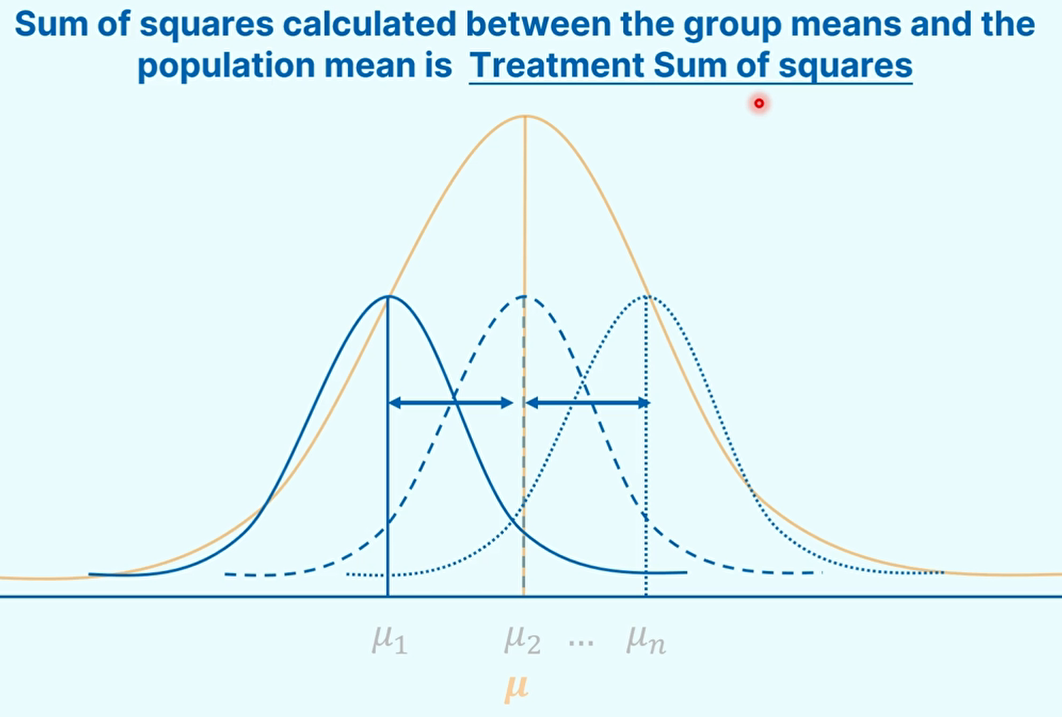
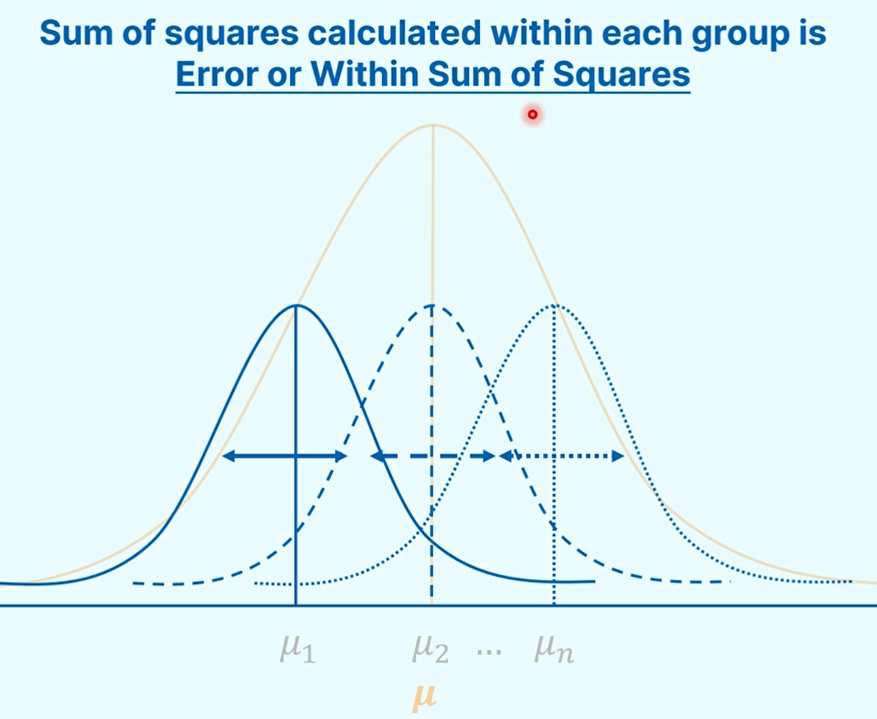

In [ ]:
# In Anova there is also population mean, Each group has own mean

# - Total Sum of Squares (TSS)
# - Sum of Squares between groups and population (TrSS) - Treatment
# - Sum of Squares within each group (ESS) - Error sum of Squares

# TSS = TrSS + ESS    

# if TrSS >> ESS => Then Treatment is causing the most of the observed deviance

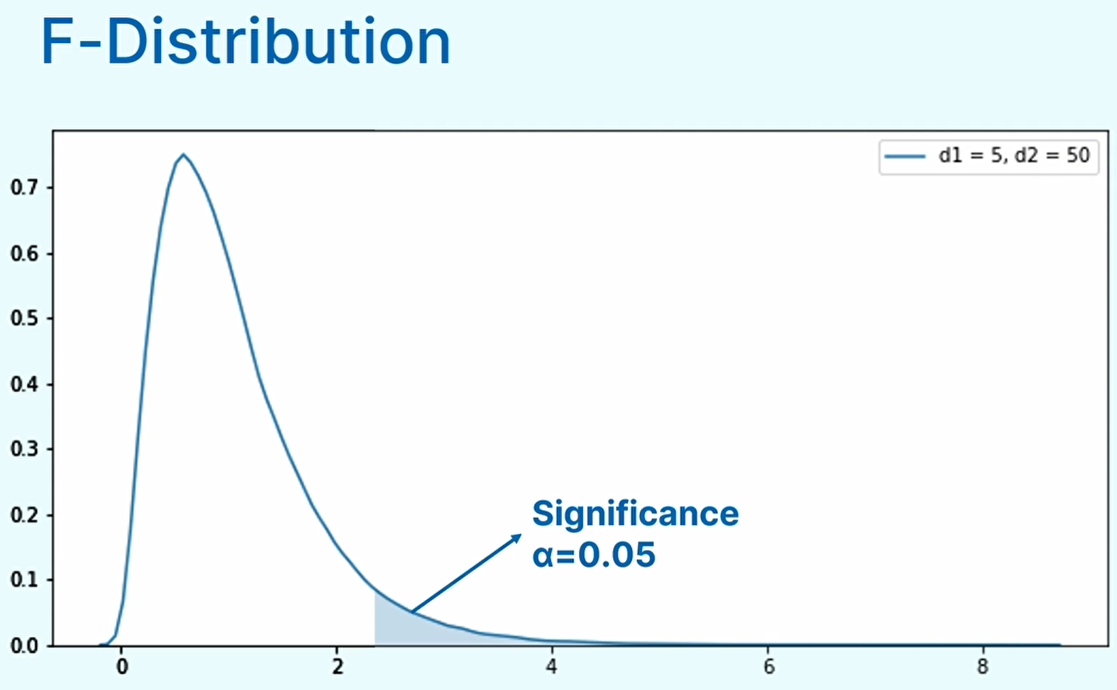

In [ ]:
# One way vs Two way Anova
# -> Anova with single treatment variable is one way Anova
# -> Anova with two treatment variables is two way Anova

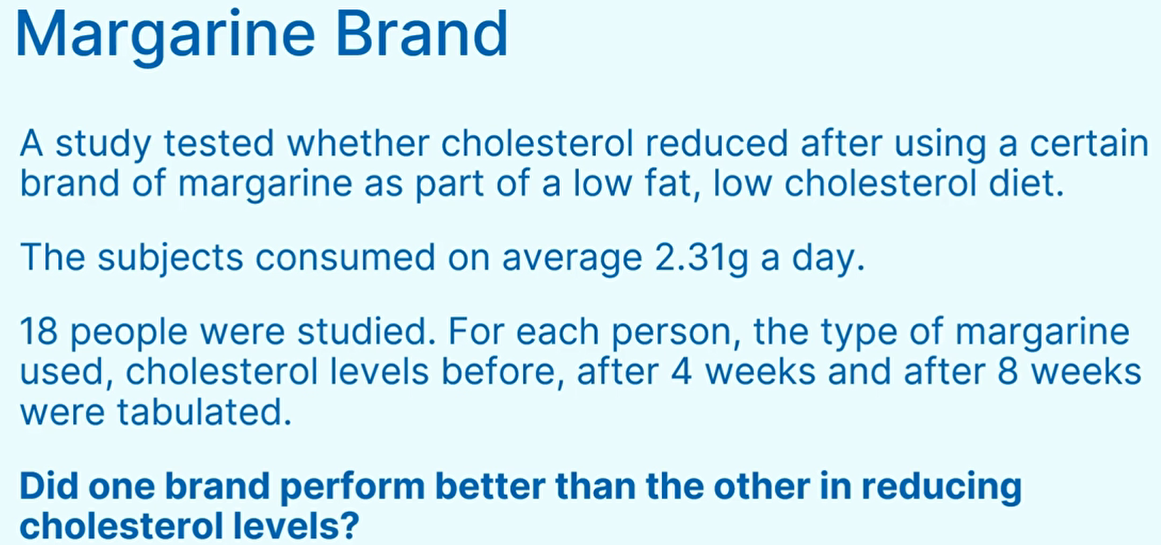

In [ ]:
# H0: m1 = m2
# Ha: m1 != m2

In [190]:

import pandas as pd 
import numpy as np
import seaborn as sn
from scipy import stats 
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from bioinfokit.analys import stat

df = pd.read_csv("../data_analysis/sources/Cholesterol.csv",)


In [191]:
df

,Before,After4weeks,After8weeks,Margarine,Diff
0,6.76,6.20,6.13,A,-0.63
1,4.80,4.27,4.15,A,NaN
2,7.49,7.12,7.05,A,NaN
3,5.05,4.63,4.67,A,NaN
4,3.91,3.70,3.66,A,NaN
5,6.17,5.56,5.51,A,NaN
6,7.67,7.11,6.96,A,NaN
7,7.34,6.84,6.82,A,NaN
8,5.13,4.52,4.45,A,NaN
9,6.42,5.83,5.75,B,NaN


<Axes: xlabel='Before', ylabel='Density'>

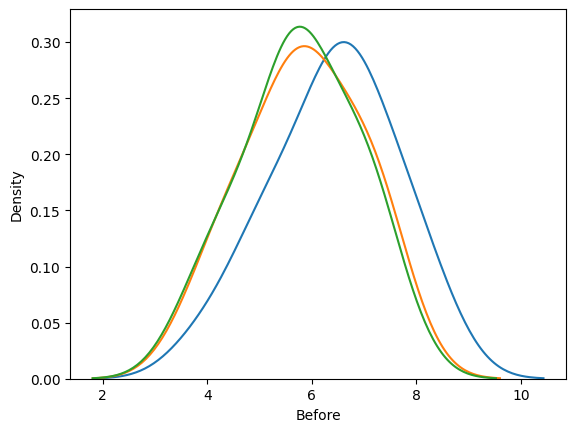

In [24]:
sn.kdeplot(df.Before)
sn.kdeplot(df.After4weeks)
sn.kdeplot(df.After8weeks)

In [97]:
df['loss4'] = df.After4weeks - df.Before
df['loss8'] = df.After8weeks - df.Before
df

,Before,After4weeks,After8weeks,Margarine,Diff,loss4,loss8
0,6.76,6.20,6.13,A,-0.63,-0.56,-0.63
1,4.80,4.27,4.15,A,NaN,-0.53,-0.65
2,7.49,7.12,7.05,A,NaN,-0.37,-0.44
3,5.05,4.63,4.67,A,NaN,-0.42,-0.38
4,3.91,3.70,3.66,A,NaN,-0.21,-0.25
5,6.17,5.56,5.51,A,NaN,-0.61,-0.66
6,7.67,7.11,6.96,A,NaN,-0.56,-0.71
7,7.34,6.84,6.82,A,NaN,-0.50,-0.52
8,5.13,4.52,4.45,A,NaN,-0.61,-0.68
9,6.42,5.83,5.75,B,NaN,-0.59,-0.67


<Axes: xlabel='Margarine', ylabel='loss4'>

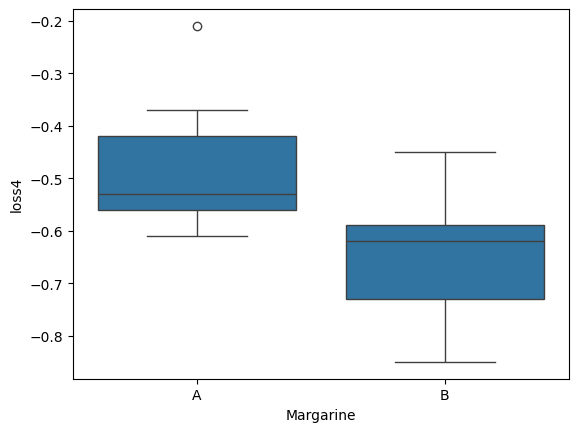

In [26]:
sn.boxplot(x=df.Margarine, y=df.loss4)

<Axes: xlabel='Margarine', ylabel='loss8'>

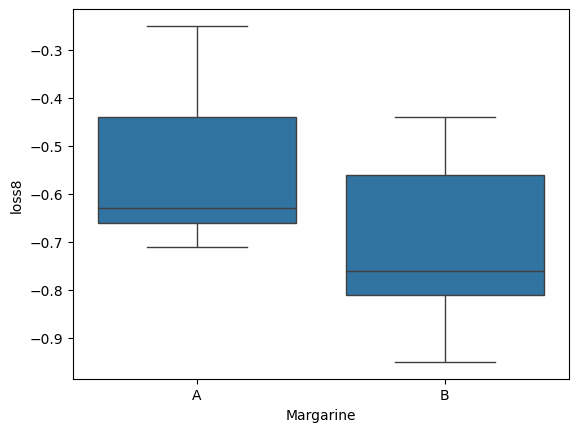

In [27]:
sn.boxplot(x=df.Margarine, y=df.loss8)

In [98]:
stats.ttest_ind(a=df.loss4[df.Margarine=='A'],
                b=df.loss4[df.Margarine=='B'], equal_var=True)

TtestResult(statistic=np.float64(2.5185987910477103), pvalue=np.float64(0.022803946887595905), df=np.float64(16.0))

In [99]:
stats.ttest_ind(a=df.loss8[df.Margarine=="A"],
                b=df.loss8[df.Margarine=='B'], equal_var=True)

TtestResult(statistic=np.float64(2.1528553803300796), pvalue=np.float64(0.046933443853219216), df=np.float64(16.0))

In [100]:
# Anova
formula = 'loss8 ~ C(Margarine)'
model = ols(formula, df).fit()
anova_table = anova_lm(model)
print(anova_table)

# Reject the Null hypthesis - there is difference in drop in cholesterol between A and B after 8 weeks

                df    sum_sq   mean_sq         F    PR(>F)
C(Margarine)   1.0  0.121689  0.121689  4.634786  0.046933
Residual      16.0  0.420089  0.026256       NaN       NaN


In [101]:
formula = 'loss4 ~ C(Margarine)'
model = ols(formula, df).fit()
aov_table = anova_lm(model)
print(aov_table)

# Reject the Null hypthesis - there is difference in drop in cholesterol between A and B after 4 weeks

                df    sum_sq   mean_sq        F    PR(>F)
C(Margarine)   1.0  0.116806  0.116806  6.34334  0.022804
Residual      16.0  0.294622  0.018414      NaN       NaN


# Two way ANOVA >> Diet + Gender
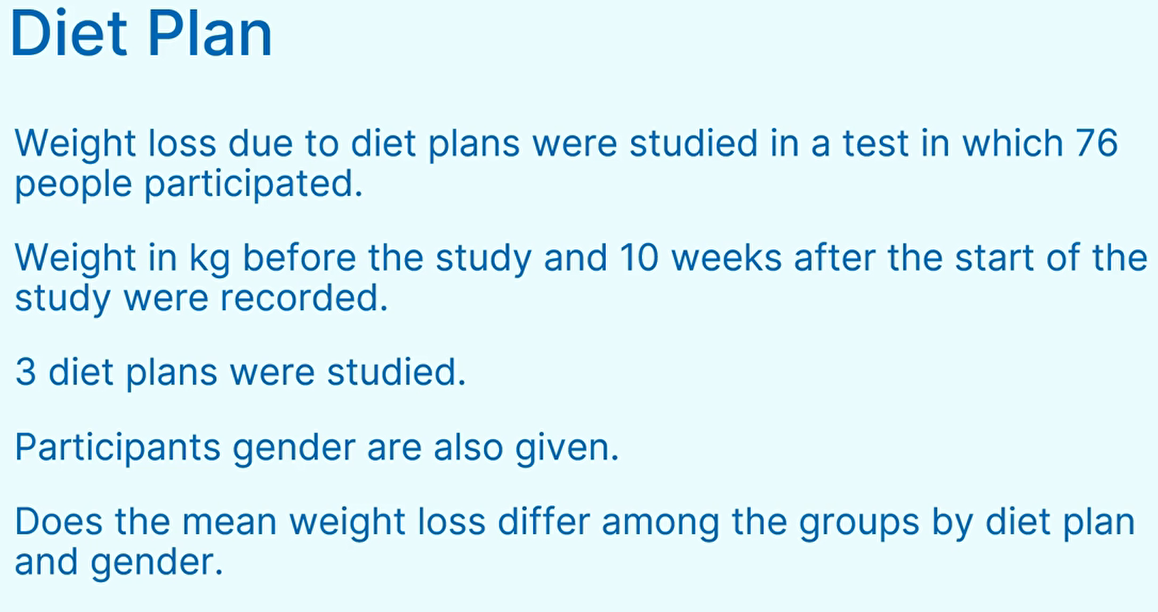
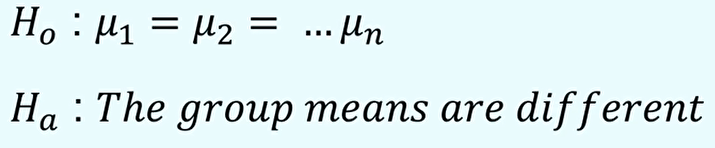

In [192]:
from scipy import stats
# from bionfokit.analys import stat

df = pd.read_csv('../data_analysis/sources/diet.csv')
df

,id,gender,age,height,diet.type,initial.weight,final.weight
0,1,Female,22,159,A,58,54.2
1,2,Female,46,192,A,60,54.0
2,3,Female,55,170,A,64,63.3
3,4,Female,33,171,A,64,61.1
4,5,Female,50,170,A,65,62.2
...,...,...,...,...,...,...,...
71,74,Male,35,183,C,83,80.2
72,75,Male,49,177,C,84,79.9
73,76,Male,28,164,C,85,79.7
74,77,Male,40,167,C,87,77.8


In [193]:
df['preweight'] = df["initial.weight"]
df['after6weeks'] = df['final.weight']
df['diet'] = df['diet.type']
df

,id,gender,age,height,diet.type,initial.weight,final.weight,preweight,after6weeks,diet
0,1,Female,22,159,A,58,54.2,58,54.2,A
1,2,Female,46,192,A,60,54.0,60,54.0,A
2,3,Female,55,170,A,64,63.3,64,63.3,A
3,4,Female,33,171,A,64,61.1,64,61.1,A
4,5,Female,50,170,A,65,62.2,65,62.2,A
...,...,...,...,...,...,...,...,...,...,...
71,74,Male,35,183,C,83,80.2,83,80.2,C
72,75,Male,49,177,C,84,79.9,84,79.9,C
73,76,Male,28,164,C,85,79.7,85,79.7,C
74,77,Male,40,167,C,87,77.8,87,77.8,C


In [194]:
df['wtloss'] = df.preweight - df.after6weeks
df.shape

(76, 11)

<Axes: xlabel='gender', ylabel='wtloss'>

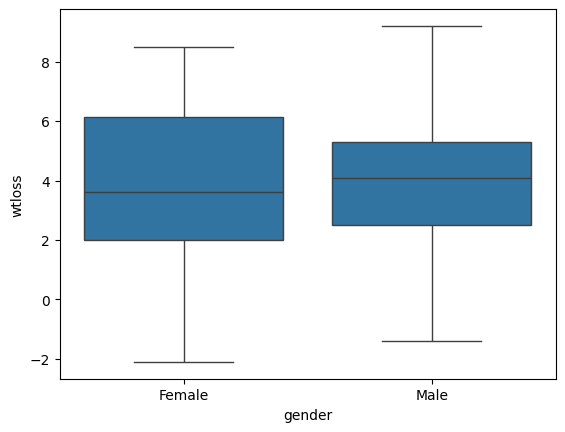

In [131]:
# Diet + Gender ---> wtloss
sn.boxplot(x=df.gender, y=df.wtloss)

<Axes: xlabel='diet.type', ylabel='wtloss'>

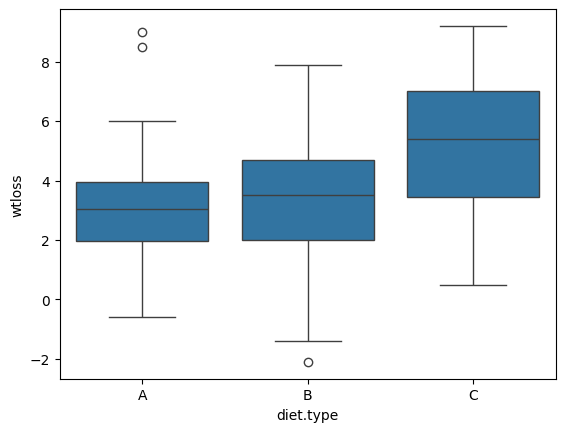

In [65]:
sn.boxplot(x=df['diet.type'], y=df.wtloss)

<Axes: xlabel='diet.type', ylabel='wtloss'>

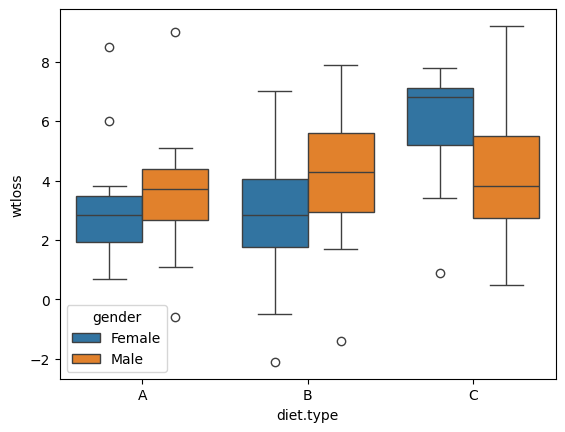

In [62]:
sn.boxplot(x=df['diet.type'], y=df.wtloss, hue=df.gender)

<Axes: xlabel='diet.type', ylabel='wtloss'>

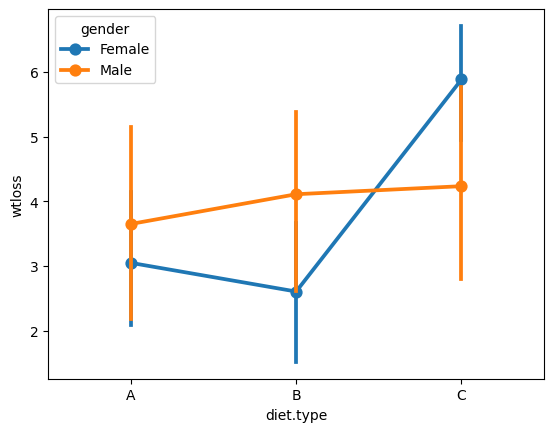

In [68]:
sn.pointplot(x='diet.type', y='wtloss', hue='gender', data=df)

C:\Users\nuri\AppData\Local\Temp\ipykernel_2988\2394705822.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0)` for the same effect.

  sn.pointplot(x="diet.type", y="wtloss", hue="gender", data=df, ci=0);


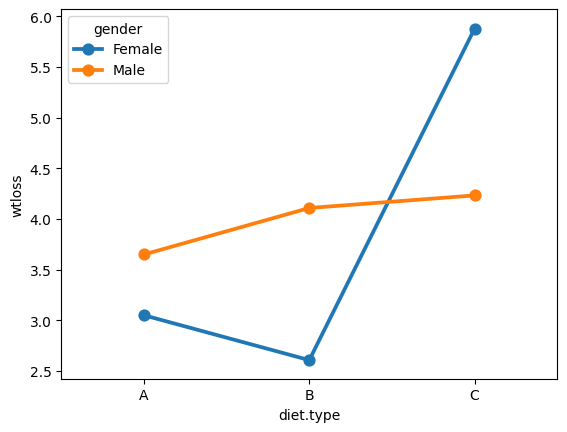

In [ ]:
sn.pointplot(x="diet.type", y="wtloss", hue="gender", data=df, ci=0)

In [139]:
# Anova - one way, Gender wtloss

formula = 'wtloss ~ C(gender)'
model = ols(formula, df).fit()
aov_table = anova_lm(model)
aov_table
# !Failed to reject the Null hypothesis
#! Gender doesnt have effect on wtloss
#! C(gender)|df 1 --> there is two gender so n - 1 | 2 -1 = 1; Residual|df 76-2 = 74

,df,sum_sq,mean_sq,F,PR(>F)
C(gender),1.0,0.278485,0.278485,0.043786,0.834827
Residual,74.0,470.650331,6.360140,NaN,NaN


In [140]:
# Anova - one way, Diet wtloss

formula = 'wtloss ~ C(diet)'
model = ols(formula, df).fit()
aov_table = anova_lm(model)
aov_table

#! Reject the NULL hypothesis
#! There is effect of diet on wtloss
#! C(gender)|df 2 --> there is 3 type of diet so n - 1 | 3 -1 = 2; Residual|df 76-3 = 73

,df,sum_sq,mean_sq,F,PR(>F)
C(diet),2.0,60.527008,30.263504,5.383104,0.006596
Residual,73.0,410.401807,5.621943,NaN,NaN


In [195]:
# ANOVA - 2 WAY: Diet + Gender

formula = 'wtloss ~ C(gender) + C(diet)'
model = ols(formula, df).fit()
two_way = anova_lm(model)
two_way

,df,sum_sq,mean_sq,F,PR(>F)
C(gender),1.0,0.278485,0.278485,0.048877,0.825655
C(diet),2.0,60.417220,30.208610,5.301912,0.007112
Residual,72.0,410.233112,5.697682,NaN,NaN


In [196]:
mapping = {"A": 1, "B": 2, "C": 3}
    
df["diet_num"] = df.diet.map(mapping)
df

,id,gender,age,height,diet.type,initial.weight,final.weight,preweight,after6weeks,diet,wtloss,diet_num
0,1,Female,22,159,A,58,54.2,58,54.2,A,3.8,1
1,2,Female,46,192,A,60,54.0,60,54.0,A,6.0,1
2,3,Female,55,170,A,64,63.3,64,63.3,A,0.7,1
3,4,Female,33,171,A,64,61.1,64,61.1,A,2.9,1
4,5,Female,50,170,A,65,62.2,65,62.2,A,2.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...
71,74,Male,35,183,C,83,80.2,83,80.2,C,2.8,3
72,75,Male,49,177,C,84,79.9,84,79.9,C,4.1,3
73,76,Male,28,164,C,85,79.7,85,79.7,C,5.3,3
74,77,Male,40,167,C,87,77.8,87,77.8,C,9.2,3


In [ ]:
# Diet has an effect but not Gender
# Howoever, the group means are different

# Reject Null hypothesis


In [200]:
# from bioinfokit.analys import stat

# 1. Create a clean, strictly numeric copy of the dataframe
df_numeric = df[["wtloss", "gender", "diet_num"]].copy()

# 2. Map string categories to numeric integers so .mean() does not fail
df_numeric["gender"] = df_numeric["gender"].map({"Male": 1, "Female": 2})
# Note: Adjust the mapping dictionary keys ('Male'/'Female') to match your exact string data

# 3. Run bioinfokit using the numeric factors
res = stat()
res.tukey_hsd(
    df=df_numeric,
    res_var="wtloss",
    xfac_var=["gender", "diet_num"],
    anova_model="wtloss ~ C(diet_num) + C(gender) + C(diet_num):C(gender)",
)

res.tukey_summary


,group1,group2,Diff,Lower,Upper,q-value,p-value
0,"(2, 1)","(2, 2)",0.442857,-2.124927,3.010641,0.714649,0.900000
1,"(2, 1)","(2, 3)",2.830000,0.305375,5.354625,4.644909,0.019125
2,"(2, 1)","(1, 1)",0.600000,-2.212866,3.412866,0.883873,0.900000
3,"(2, 1)","(1, 2)",1.059091,-1.678176,3.796358,1.603259,0.852310
4,"(2, 1)","(1, 3)",1.183333,-1.489301,3.855968,1.834658,0.759628
5,"(2, 2)","(2, 3)",3.272857,0.748232,5.797482,5.371775,0.004009
6,"(2, 2)","(1, 1)",1.042857,-1.770009,3.855724,1.536255,0.879145
7,"(2, 2)","(1, 2)",1.501948,-1.235319,4.239215,2.273659,0.583804
8,"(2, 2)","(1, 3)",1.626190,-1.046444,4.298825,2.521271,0.483835
9,"(2, 3)","(1, 1)",2.230000,-0.543524,5.003524,3.331660,0.186204


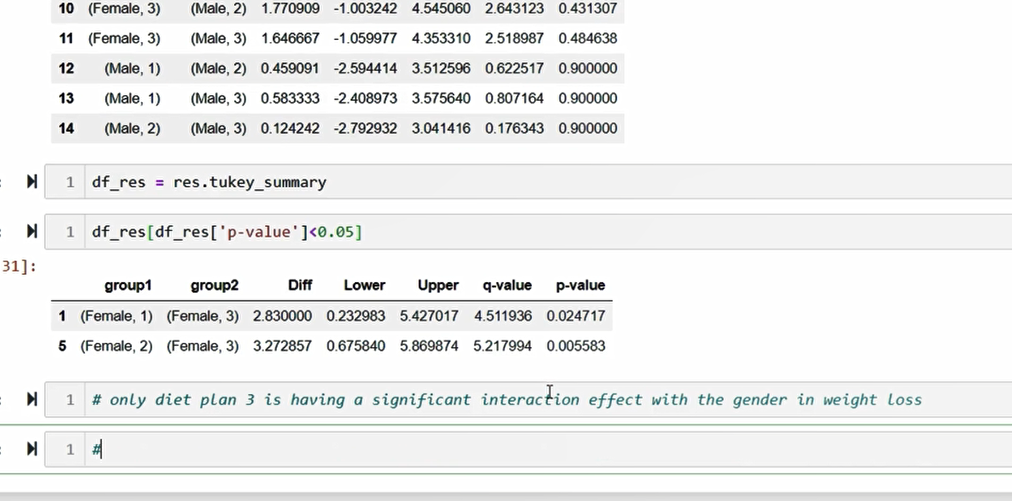

In [211]:
res_new = res.tukey_summary
res_new[res_new['p-value'] < 0.05]

,group1,group2,Diff,Lower,Upper,q-value,p-value
1,"(2, 1)","(2, 3)",2.830000,0.305375,5.354625,4.644909,0.019125
5,"(2, 2)","(2, 3)",3.272857,0.748232,5.797482,5.371775,0.004009


In [213]:
movies = pd.read_csv('../data_analysis/sources/Movies.csv')
movies.head()

,Title,Year,Genre,Duration,Director,Rating,Popularity
0,What Is It?,2005,Drama,72,Crispin Glover,5.6,21.83
1,Glitter,2001,Drama,104,Vondie Curtis-Hall,2.2,81.69
2,The Attic Expeditions,2001,Comedy,100,Jeremy Kasten,5.0,42.08
3,Men in Black II,2002,Action,88,Barry Sonnenfeld,6.2,98.60
4,Star Wars: Episode II - Attack of the Clones,2002,Action,142,George Lucas,6.5,99.58


In [227]:
# Duration => Numeric to Categorical
# Genres => Top 3 Genres

movies['duration_cat'] = np.where(movies.Duration < 90, "Short", np.where(movies.Duration < 120, "Median", "Long"))
movies.head()

,Title,Year,Genre,Duration,Director,Rating,Popularity,duration_cat
0,What Is It?,2005,Drama,72,Crispin Glover,5.6,21.83,Short
1,Glitter,2001,Drama,104,Vondie Curtis-Hall,2.2,81.69,Median
2,The Attic Expeditions,2001,Comedy,100,Jeremy Kasten,5.0,42.08,Median
3,Men in Black II,2002,Action,88,Barry Sonnenfeld,6.2,98.60,Short
4,Star Wars: Episode II - Attack of the Clones,2002,Action,142,George Lucas,6.5,99.58,Long


In [229]:
movies.groupby('Genre').count().sort_values('duration_cat', ascending=False)[:3]

,Title,Year,Duration,Director,Rating,Popularity,duration_cat
Genre,,,,,,,
Comedy,1670,1670,1670,1670,1670,1670,1670
Drama,1187,1187,1187,1187,1187,1187,1187
Action,751,751,751,751,751,751,751


In [245]:
moviesTopGenres = movies[movies.Genre.isin(['Comedy', 'Drama', 'Action'])]
moviesTopGenres

,Title,Year,Genre,Duration,Director,Rating,Popularity,duration_cat
0,What Is It?,2005,Drama,72,Crispin Glover,5.6,21.83,Short
1,Glitter,2001,Drama,104,Vondie Curtis-Hall,2.2,81.69,Median
2,The Attic Expeditions,2001,Comedy,100,Jeremy Kasten,5.0,42.08,Median
3,Men in Black II,2002,Action,88,Barry Sonnenfeld,6.2,98.60,Short
4,Star Wars: Episode II - Attack of the Clones,2002,Action,142,George Lucas,6.5,99.58,Long
...,...,...,...,...,...,...,...,...
5263,President Evil,2018,Comedy,81,Richard Lowry,4.0,15.02,Short
5267,A Christmas Prince: The Royal Wedding,2018,Drama,92,John Schultz,5.3,70.36,Median
5268,Jurassic Galaxy,2018,Action,74,"James Kondelik, Jon Kondelik",2.3,2.59,Short
5271,The Princess Switch,2018,Comedy,101,Mike Rohl,6.0,80.21,Median


<Axes: xlabel='Genre', ylabel='Rating'>

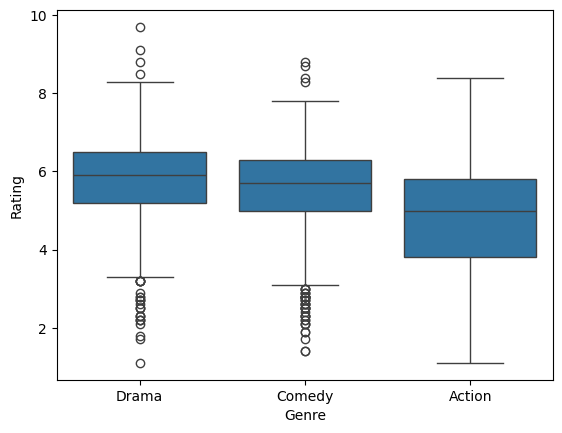

In [248]:
import seaborn as sn
sn.boxplot(x=moviesTopGenres.Genre, y=moviesTopGenres.Rating)

<Axes: xlabel='duration_cat', ylabel='Rating'>

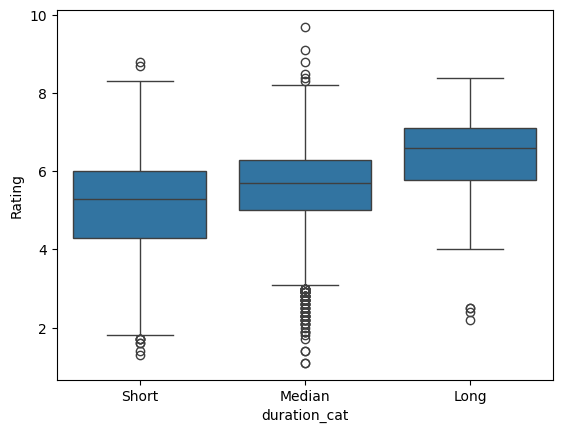

In [250]:
sn.boxplot(x=moviesTopGenres.duration_cat, y=moviesTopGenres.Rating)

<Axes: xlabel='duration_cat', ylabel='Rating'>

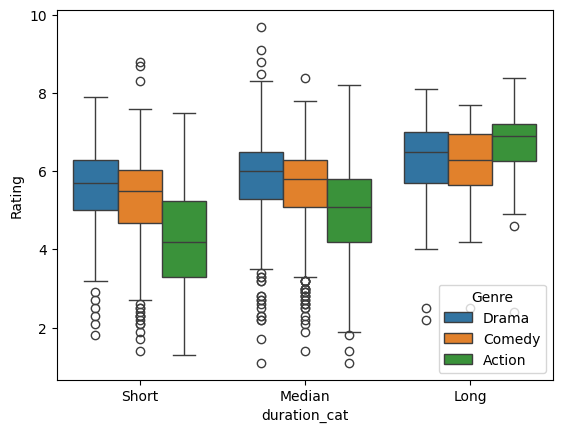

In [254]:
sn.boxplot(x=moviesTopGenres.duration_cat, y=moviesTopGenres.Rating, hue=moviesTopGenres.Genre)

<Axes: xlabel='Genre', ylabel='Rating'>

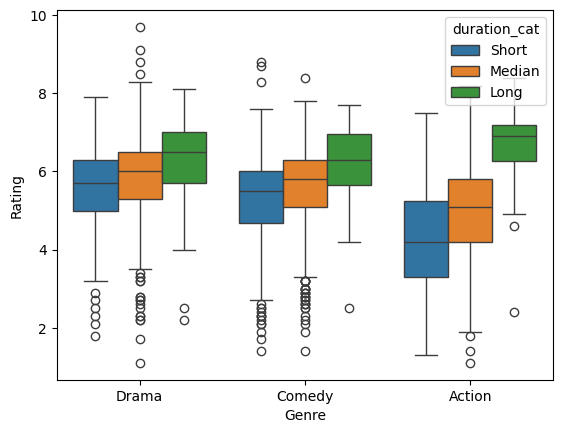

In [255]:
sn.boxplot(
    x=moviesTopGenres.Genre, y=moviesTopGenres.Rating, hue=moviesTopGenres.duration_cat)


<Axes: xlabel='duration_cat', ylabel='Rating'>

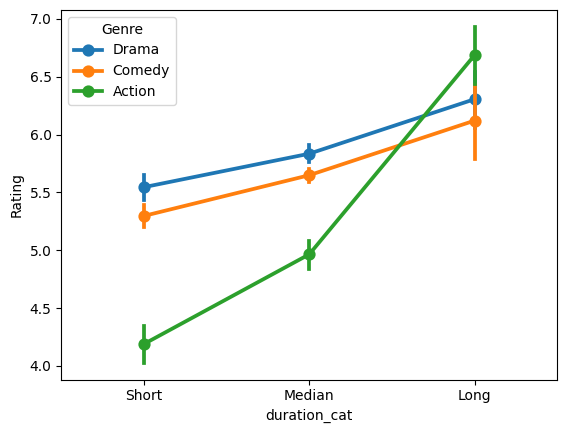

In [257]:
sn.pointplot(x='duration_cat', y='Rating', hue='Genre', data=moviesTopGenres)

C:\Users\nuri\AppData\Local\Temp\ipykernel_2988\2246701880.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0)` for the same effect.

  sn.pointplot(x="duration_cat", y="Rating", hue="Genre", data=moviesTopGenres, ci=0);


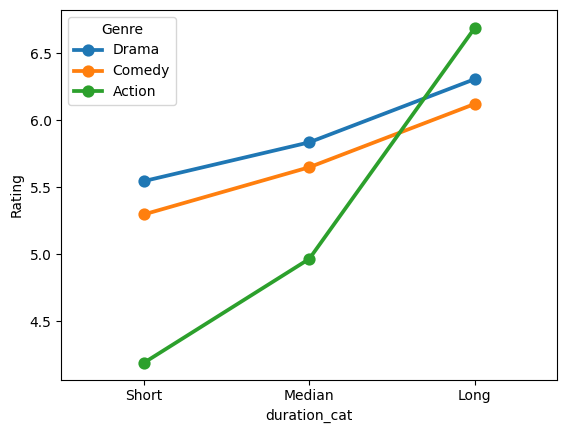

In [259]:
sn.pointplot(x="duration_cat", y="Rating", hue="Genre", data=moviesTopGenres, ci=0);


In [ ]:
# Anova - one way, Genre
formula = 'Rating ~ C(Genre)'
model = ols(formula, moviesTopGenres).fit()
anov_tab = anova_lm(model)
anov_tab

# !Reject NUll hypothesis
# !There is huge difference between Rating vs Genre
# !So group means are difference among the genres 

,df,sum_sq,mean_sq,F,PR(>F)
C(Genre),2.0,434.410420,217.205210,168.303785,1.319696e-70
Residual,3605.0,4652.449023,1.290555,NaN,NaN


In [266]:
# Anova - one way, categorical duration
formula = 'Rating ~ C(duration_cat)'
model = ols(formula, moviesTopGenres).fit()
ano_tab = anova_lm(model)
ano_tab

# !Reject NUll hypothesis
# !There is huge difference between Rating vs Categorical Duration

# ! So both genre and duration_cat has effect on Rating

,df,sum_sq,mean_sq,F,PR(>F)
C(duration_cat),2.0,316.141969,158.070984,119.446583,5.908315e-51
Residual,3605.0,4770.717474,1.323361,NaN,NaN


In [268]:
# Anova - 2 way
formula = "Rating ~ C(Genre) + C(duration_cat)"
model = ols(formula, moviesTopGenres).fit()
ano_tab = anova_lm(model)
ano_tab

,df,sum_sq,mean_sq,F,PR(>F)
C(Genre),2.0,434.410420,217.205210,180.029812,3.009753e-75
C(duration_cat),2.0,305.444704,152.722352,126.583411,7.429675e-54
Residual,3603.0,4347.004319,1.206496,NaN,NaN


In [288]:
# Tukey HSD hones
df_numeric = moviesTopGenres[["Rating", "Genre", "duration_cat"]].copy()

df_numeric["Genre"] = df_numeric["Genre"].map({"Action": 1, "Drama": 2, "Comedy": 3})
df_numeric["duration_cat"] = df_numeric["duration_cat"].map(
    {"Short": 90, "Medium": 100, "Long": 120}
)

res = stat()
res.tukey_hsd(
    df=df_numeric,
    res_var="Rating",
    xfac_var=["Genre", "duration_cat"],
    anova_model="Rating ~ C(duration_cat) + C(Genre) + C(duration_cat):C(Genre)",
)

res.tukey_summary

,group1,group2,Diff,Lower,Upper,q-value,p-value
0,"(2, 90.0)","(2, 120.0)",0.760809,0.357300,1.164317,7.610487,0.001000
1,"(2, 90.0)","(1, 90.0)",1.356295,1.079644,1.632947,19.788393,0.001000
2,"(2, 90.0)","(1, 120.0)",1.142136,0.672952,1.611320,9.825715,0.001000
3,"(2, 90.0)","(3, 90.0)",0.248633,0.015325,0.481942,4.301494,0.028941
4,"(2, 90.0)","(3, 120.0)",0.575566,0.049947,1.101185,4.419913,0.022360
5,"(2, 120.0)","(1, 90.0)",2.117104,1.704204,2.530004,20.696014,0.001000
6,"(2, 120.0)","(1, 120.0)",0.381327,-0.179105,0.941759,2.746404,0.378105
7,"(2, 120.0)","(3, 90.0)",1.009442,0.624237,1.394647,10.577397,0.001000
8,"(2, 120.0)","(3, 120.0)",0.185243,-0.423219,0.793704,1.228845,0.900000
9,"(1, 90.0)","(1, 120.0)",2.498431,2.021146,2.975716,21.129004,0.001000


In [290]:
res_filter = res.tukey_summary
res_filter[res_filter['p-value'] < 0.05].shape

(12, 7)